# Simulating a dwarf novae in LSST

The purpose of this notebook is to produce a simulation of the timeseries photometry that Rubin's LSST could deliver for an example Dwarf Nova, given the baseline_v5.0 survey strategy that will be adopted for the first years of the survey.  

This notebook is based on a similar simulation written by Anibal Verala for microlensing events, adapted and documented by Rachel Street. 

Rubin Observatory has built sophisticated open-source simulation software, [rubin_sim](https://github.com/lsst/rubin_sim), which has been used to explore alternative observing strategies in order to optimize the survey design.  

Full installation instructions can be found at the link above. 

In [1]:
import os
import numpy as np
import pandas as pd
import math
import copy
import matplotlib.pyplot as plt
%matplotlib inline
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table, Column
from astropy.io import fits
from scipy import stats
from scipy.interpolate import UnivariateSpline
from scipy.interpolate import interp1d
#--------------------------------------
import rubin_sim.phot_utils as phot_utils
import rubin_sim.maf as maf
from rubin_sim.phot_utils import signaltonoise, PhotometricParameters
from rubin_sim.data import get_data_dir
from rubin_sim.data import get_baseline
import healpy as hp
#---------------------------------------

## Set-up
Rubin_sim provides a range of information about the Rubin telescope and instrument that we'll need for the simulation, so we'll start by loading the information on the filter bandpasses and their expected throughputs.  

In [2]:
def set_photometric_parameters(exptime, nexp, readnoise=None):
    """
    Load photometric noise properties from the rubin_sim utilities
    """
    # readnoise = None will use the default (8.8 e/pixel). Readnoise should be in electrons/pixel.
    photParams = PhotometricParameters(exptime=exptime, nexp=nexp, readnoise=readnoise)
    return photParams

In [3]:
# Load the LSST filterset and expected throughput in each filter
LSST_BandPass = {}
lsst_filterlist = 'ugrizy'
for f in lsst_filterlist:
    LSST_BandPass[f] = phot_utils.Bandpass()
    # print(os.path.join(get_data_dir(), 'throughputs', 'baseline', f'total_{f}.dat'))
    LSST_BandPass[f].read_throughput(os.path.join(get_data_dir(), 'throughputs', 'baseline', f'total_{f}.dat'))
photParams = set_photometric_parameters(30,1)

## Target information

LSST includes a number of sub-surveys, such as the Wide-Fast-Deep (WFD), Deep Drilling Field (DDFs) and the Galactic Plane survey, all of which have different cadence choices and balance of exposures in different filters.  So before we can figure out what cadence our simulated target will receive, we need to know where it is in the sky.  

In [4]:
# Target coordinates
# Example star in the Plane but outside of the Bulge
RA = 281.1125
Dec = -13.88194

print('Target sky location: RA=' + str(RA) + 'deg, Dec=' + str(Dec))

Target sky location: RA=281.1125deg, Dec=-13.88194


For this simulation, we also need an example of the lightcurve shape.  
We will derive this from a real-world example detected by OGLE. 

In [5]:
file_path = '/Users/rstreet/cassiopeia/GrantProposals/2025/NSF_AAG/LSSTMicrolensing/figures/OGLE-BLG-DN-0366_multiband_lc.fits'

# The more extensive OGLE I lightcurve is in table extension 2
target_phot = Table.read(file_path, format='fits', hdu=2)
print(target_phot)

     HJD       mag   mag_error
------------- ------ ---------
2452125.67487 19.062     0.101
2452129.72762 18.792     0.042
2452132.67057 18.908     0.051
2452136.57402 18.867     0.068
2452141.58621 18.865     0.051
2452144.67284 18.765     0.048
2452160.62853 18.828     0.073
2452170.56941 19.045     0.059
2452178.58019 18.713     0.103
2452211.53382 18.694     0.081
          ...    ...       ...
2456584.54004 18.895     0.083
2456585.49285 18.807     0.072
2456585.54262 18.962     0.087
2456586.51626 19.018     0.086
2456590.50831 18.808     0.059
2456590.53213 18.899     0.078
2456590.55115 18.789     0.062
2456592.51969 18.998     0.078
2456593.51866 18.693     0.055
2456595.50683 18.896     0.068
Length = 9763 rows


OGLE lightcurves can be over 25yrs long which is excessive for these purposes.  Here we trim the lightcurve to a single season of data.

In [6]:
tmin = 2456000.0
tmax = tmin + 250.0
idx1 = np.where(target_phot['HJD'] >= tmin)[0]
idx2 = np.where(target_phot['HJD'] <= tmax)[0]
mask = list(set(idx1).intersection(set(idx2)))

target_phot = target_phot[mask] 
print(target_phot)

     HJD       mag   mag_error
------------- ------ ---------
2456002.80294 18.893     0.091
2456002.83579 18.716     0.069
 2456002.8765 18.961     0.073
2456003.84965 18.838     0.072
2456003.89637 18.763     0.049
2456004.78147 18.718     0.047
 2456004.8294 18.864     0.043
2456004.87782 18.769     0.044
2456004.91577 18.826     0.058
2456005.78397 18.788     0.042
          ...    ...       ...
2456223.57326 18.748      0.06
2456224.51446 18.744     0.078
2456226.51338 18.822     0.081
2456227.54075 19.029     0.102
2456231.53271 18.771     0.093
2456233.51775   18.8     0.064
2456234.50678 18.826     0.072
2456238.51131  18.75     0.067
2456239.51335 18.795     0.069
2456242.50857 18.872     0.114
Length = 2265 rows


In [9]:
bin_window = 2.0
time_bins = np.arange(target_phot['HJD'].min(), target_phot['HJD'].max(), bin_window)

mag = [] 
mag_err = []
for tbin in time_bins:
    idx1 = np.where(target_phot['HJD'] >= tbin)[0]
    idx2 = np.where(target_phot['HJD'] <= tbin+bin_window)[0] 
    mask = list(set(idx1).intersection(set(idx2)))
    mag.append(np.median(target_phot['mag'][mask])) 
    mag_err.append(np.sqrt( (target_phot['mag_error'][mask]**2).sum() ))

mask = np.where(~np.isnan(np.array(mag)))[0]
binned_target_phot = Table([
    Column(name='HJD', data=time_bins[mask]),
    Column(name='mag', data=np.array(mag)[mask]), 
    Column(name='mag_error', data=np.array(mag_err)[mask])
])

(np.float64(2455990.8176585),
 np.float64(2456254.4938515),
 np.float64(19.5),
 np.float64(18.3017))

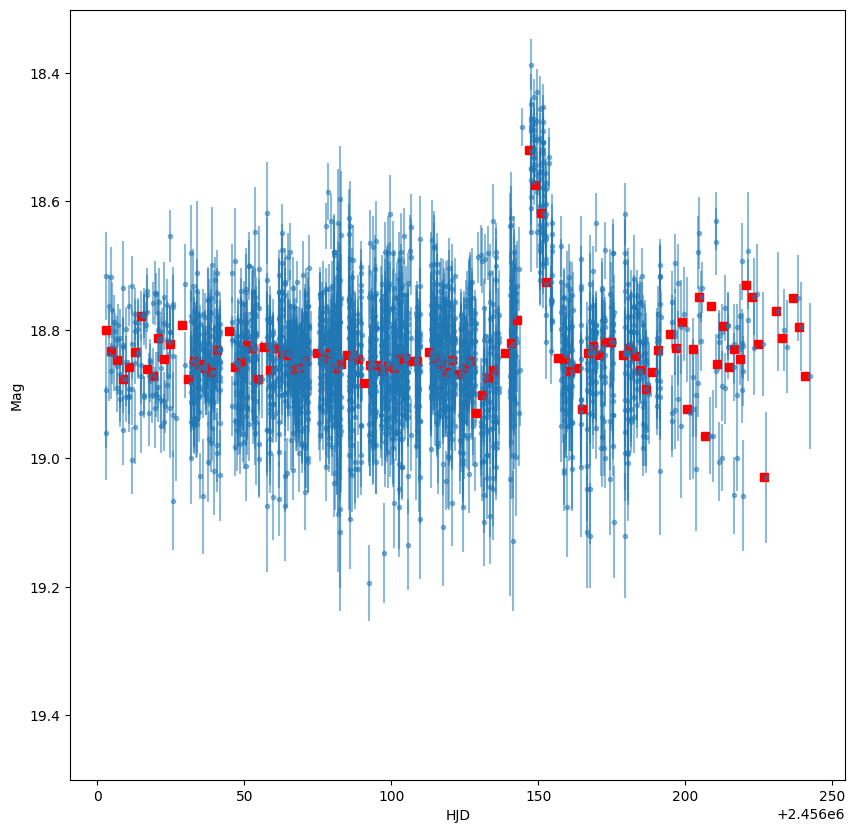

In [10]:
fig, ax = plt.subplots(1,1, figsize=(10,10))

ax.errorbar(target_phot['HJD'], target_phot['mag'], yerr=target_phot['mag_error'], marker='.', linestyle=' ', label='OGLE', alpha=0.5)

ax.plot(binned_target_phot['HJD'], binned_target_phot['mag'], c='r', marker='s', linestyle=' ', label='binned')

ax.set_xlabel('HJD')
ax.set_ylabel('Mag')
[xmin, xmax, ymin, ymax] = plt.axis()
ymax = 19.5
plt.axis([xmin, xmax, ymax, ymin])


## LSST Survey Simulation

Next we need the information for the LSST survey strategy.  This is provided by Rubin Project for all the alternative strategy simulations ("opsims") they have explored in the form of a database containing the sequence of exposures and their properties as realised under that particular strategy.  baseline_v5.0.1 is the opsim database for the latest iteration of the survey strategy, as described in the Phase 3 report from the SCOC.  This is the strategy that Rubin will use for at least the first couple of years.  After that, the real-world performance will be reviewed to ensure the Science Requirements are met.  

In [11]:
# Load the opsim database
baseline_file = '/Users/rstreet/rubin_sim_data/sim_baseline/baseline_v5.0.1_10yrs.db'
name = os.path.basename(baseline_file).replace('.db','')

outDir = 'temp'
resultsDb = maf.db.ResultsDb()

# This section selects which columns from the database will be loaded - in this case, the information on the 
# bandpass and MJD of each exposure, together with the 5sigma limiting magnitude.  
# We provide the target sky location at this point, so that we get the sequence of exposures corresponding to the 
# component survey(s) that cover that location.
bundleList = []
metric = maf.metrics.PassMetric(cols=['filter', 'observationStartMJD', 'fiveSigmaDepth'])
sql = ''
slicer = maf.slicers.UserPointsSlicer(ra=[RA], dec=[Dec])
bundleList.append(maf.MetricBundle(metric, slicer, sql))

example1_bg = maf.MetricBundleGroup(
    bundleList, baseline_file, out_dir=outDir)
example1_bg.run_all()
dataSlice = bundleList[0].metric_values[0]

# Rubin filterset, and the single-visit limiting magnitude in each of those filters
filters = ['u', 'g', 'r', 'i', 'z', 'y']
mag_limit = {'u': 23.7, 'g': 24.97, 'r': 24.52, 'i': 24.13, 'z': 23.56, 'y': 22.55}

In [12]:
# This section extracts the timestamps of the sequence of exposures into an array  
# for ease of later handling.
print('Total number of visits to this sky location over 10 yrs:')
time_series = {}
for f in filters:
    data = []
    # Observations in the current filter:
    fdx = np.where(dataSlice['filter'] == f)[0]
    print('  ' + f + ' n_visits= ' + str(len(fdx)))
    for i in fdx:
        jd = dataSlice['observationStartMJD'][i] + 2400000.5
        data.append(jd)
    time_series[f] = np.sort(np.array(data))

Total number of visits to this sky location over 10 yrs:
  u n_visits= 30
  g n_visits= 159
  r n_visits= 179
  i n_visits= 160
  z n_visits= 156
  y n_visits= 43


We're also going to need to know the starting and end MJDs of the LSST survey itself, in order to estimate when different years of the survey start and finish. 

In [13]:
rubin_jd_min = dataSlice['observationStartMJD'].min() + 2400000.5
rubin_jd_max = dataSlice['observationStartMJD'].max() + 2400000.5
print('JD of LSST start: ' + str(rubin_jd_min))
print('JD of LSST finish: ' + str(rubin_jd_max))

JD of LSST start: 2461156.8171131257
JD of LSST finish: 2464604.4981393395


# Simulated lightcurve

Now we want to resample the input lightcurve based on the simulated LSST cadence.  

In [14]:
# The target photometry table includes only OGLE I-band data for this object.  We need to simulate multi-band LSST lightcurves.  
# Although there are color variations to first order we just assume a constant magnitude offset between colors. 
dmag = {'u': -0.1, 'g': -0.1, 'r': -0.05, 'i': 0.0, 'z': 0.1, 'y': 0.1}

# For the purposes of the simulation, we're going to need to adjust the timestamps a little here. 
# Let's offset the timestamps of the lightcurve datapoints so that they fall during the Rubin survey. 
# We need to be careful with this in survey regions (like the WFD) that undergo rolling in different sky regions in different 
# years, as that could heavily influence the cadence.  It's also best to avoid Year 1, since most of it will be dedicated to 
# template acquisition. 
n_year = 1.0
t_offset = rubin_jd_min - binned_target_phot['HJD'].min() + n_year*365.24

# At the same time as unpacking the lightcurves, we'll create the 1D interpolation functions for each filter
lightcurves = {}
interp_lc = {}
for f in filters:
    lc = copy.deepcopy(binned_target_phot)
    
    lc['HJD'] += t_offset
    lc['mag'] += dmag[f]

    interp_lc[f] = interp1d(lc['HJD'], lc['mag'])
    
    lightcurves[f] = lc

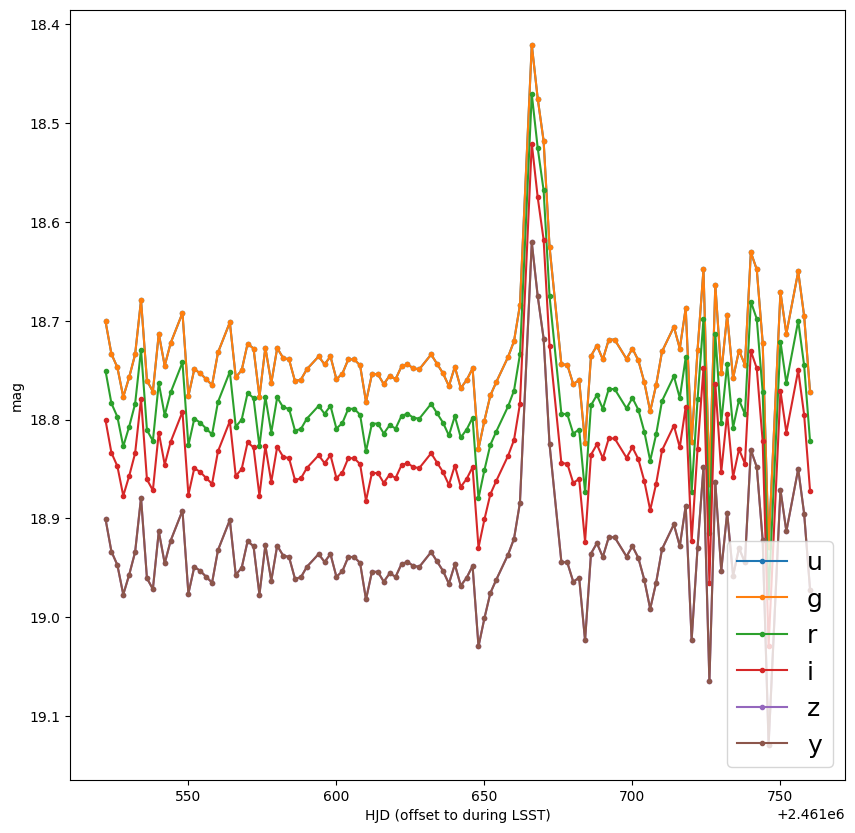

In [15]:
# As a test of the interpolation, here we plot the original data with the interpolation function applied at the same 
# timestamps
fig = plt.figure(1, (10, 10))

for f, lc in lightcurves.items():
    plt.plot(lc['HJD'], lc['mag'], marker='.', linestyle='-', label=f)
    #plt.plot(lc['HJD'], interp_lc[f](lc['HJD']), marker='.', linestyle='-')

plt.rcParams.update({'font.size': 18})
plt.xlabel('HJD (offset to during LSST)')
plt.ylabel('mag')
[xmin, xmax, ymin, ymax] = plt.axis()
plt.axis([xmin, xmax, ymax, ymin])
plt.legend(loc='lower right')

plt.show()

OK, the next step is to interpolate these lightcurves at the timestamps of observations realized by Rubin.  At this point, we need to map the filters provided in the input lightcurve to the SDSS set that Rubin uses.  Here I map these _very_ approximately - this should of course be transformed properly.  

The other issue with this lightcurve is that it is too bright for Rubin, which will saturate at around 16 mag.  So for the sake of this simulation, I'm also going to add an "extinction" term to make the target faint enough to observe.  

In [17]:
# Optional magnitude offset 
mag_offset = 0.0

In [18]:
sim_lcs = {}
for f, lc in lightcurves.items():
    
    print('Simulating ' + f + '-band observations:')
    
    # Timestamps of all Rubin observations in this filter for 10yrs
    rubin_ts = time_series[f]
    print(' -> Found ' + str(len(rubin_ts)) + ' observations of this location over 10yrs') 
    
    # Extract the set of Rubin observations during this window
    idx = (rubin_ts >= lc['HJD'].min()) & (rubin_ts <= lc['HJD'].max())
    ts = rubin_ts[idx]
    ts = np.sort(ts, axis=0)
    print(' -> Of these, ' + str(len(np.where(idx)[0])) + ' occurred during the dwarf nova')
    
    # Interpolate the SNe lightcurve to find the magnitude at each timestamp, then use 
    # the Rubin functions to calculate the photometric uncertainties that Rubin 
    # should deliver
    mag = interp_lc[f](ts) + mag_offset
    magerr = signaltonoise.calc_mag_error_m5(mag,  LSST_BandPass[f], mag_limit[f], photParams)[0]
    
    # Filter out any measurements that are either too bright or too faint for Rubin, or Nans
    jdx = (mag <= mag_limit[f]) | (mag >= 16.0) | ~np.isnan(mag)
    
    print(' -> Of the remaining datapoints, ' + str(len(np.where(jdx)[0])) + ' meet the flux requirements')
    
    new_lc = Table([
        Column(name='HJD', data=ts[jdx]),
        Column(name='mag', data=mag[jdx]),
        Column(name='mag_error', data=magerr[jdx])
    ])
    print(' -> Simulated Rubin lightcurve has ' + str(len(new_lc)) + ' datapoints\n')
    
    sim_lcs[f] = new_lc

Simulating u-band observations:
 -> Found 30 observations of this location over 10yrs
 -> Of these, 0 occurred during the dwarf nova
 -> Of the remaining datapoints, 0 meet the flux requirements
 -> Simulated Rubin lightcurve has 0 datapoints

Simulating g-band observations:
 -> Found 159 observations of this location over 10yrs
 -> Of these, 10 occurred during the dwarf nova
 -> Of the remaining datapoints, 10 meet the flux requirements
 -> Simulated Rubin lightcurve has 10 datapoints

Simulating r-band observations:
 -> Found 179 observations of this location over 10yrs
 -> Of these, 34 occurred during the dwarf nova
 -> Of the remaining datapoints, 34 meet the flux requirements
 -> Simulated Rubin lightcurve has 34 datapoints

Simulating i-band observations:
 -> Found 160 observations of this location over 10yrs
 -> Of these, 36 occurred during the dwarf nova
 -> Of the remaining datapoints, 36 meet the flux requirements
 -> Simulated Rubin lightcurve has 36 datapoints

Simulating z

Now simulate what LS4 will observe

In [22]:
def calc_ls4_errors(mag_array):
    """
    Simulate photometric uncertainties for LS4 lightcurves as a function of magnitude 
    """

    sim_mag = np.array([14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0])
    sim_mag_err = np.array([0.0001, 0.005, 0.01, 0.02, 0.08, 0.2, 0.4, 0.7])

    interp_err = interp1d(sim_mag, sim_mag_err)
    
    return interp_err(mag_array)

In [23]:
# Start the LS4 lightcurve around the time of the event.  Note this doesn't take visibility into account. 
i_ts = np.arange(lightcurves['i']['HJD'].min(), lightcurves['i']['HJD'].max(), 2.0) 
g_ts = np.arange(lightcurves['g']['HJD'].min(), lightcurves['g']['HJD'].max(), 4.0)
z_ts = np.arange(lightcurves['z']['HJD'].min(), lightcurves['z']['HJD'].max(), 4.0) 

ls4_idata = np.zeros((len(i_ts), 3)) 
ls4_idata[:,0] = i_ts 
ls4_idata[:,1] = interp_lc['i'](i_ts)
ls4_idata[:,2] = calc_ls4_errors(ls4_idata[:,1])

ls4_gdata = np.zeros((len(g_ts), 3)) 
ls4_gdata[:,0] = g_ts 
ls4_gdata[:,1] = interp_lc['g'](g_ts)
ls4_gdata[:,2] = calc_ls4_errors(ls4_gdata[:,1])

ls4_zdata = np.zeros((len(z_ts), 3)) 
ls4_zdata[:,0] = z_ts 
ls4_zdata[:,1] = interp_lc['z'](z_ts)
ls4_zdata[:,2] = calc_ls4_errors(ls4_zdata[:,1])

And now we can plot the simulated lightcurves

In [24]:
PLOT_SYMBOLS = ['o', '.', '*', 'v', '^', '<', '>', 's', 'p', 'd', 'x']
PLOT_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

LS4_PLOT_COLORS = {
    'LS4_g': '#ff7f0e', 
    'LS4_i': '#d62728', 
    'LS4_z': '#9467bd'
}

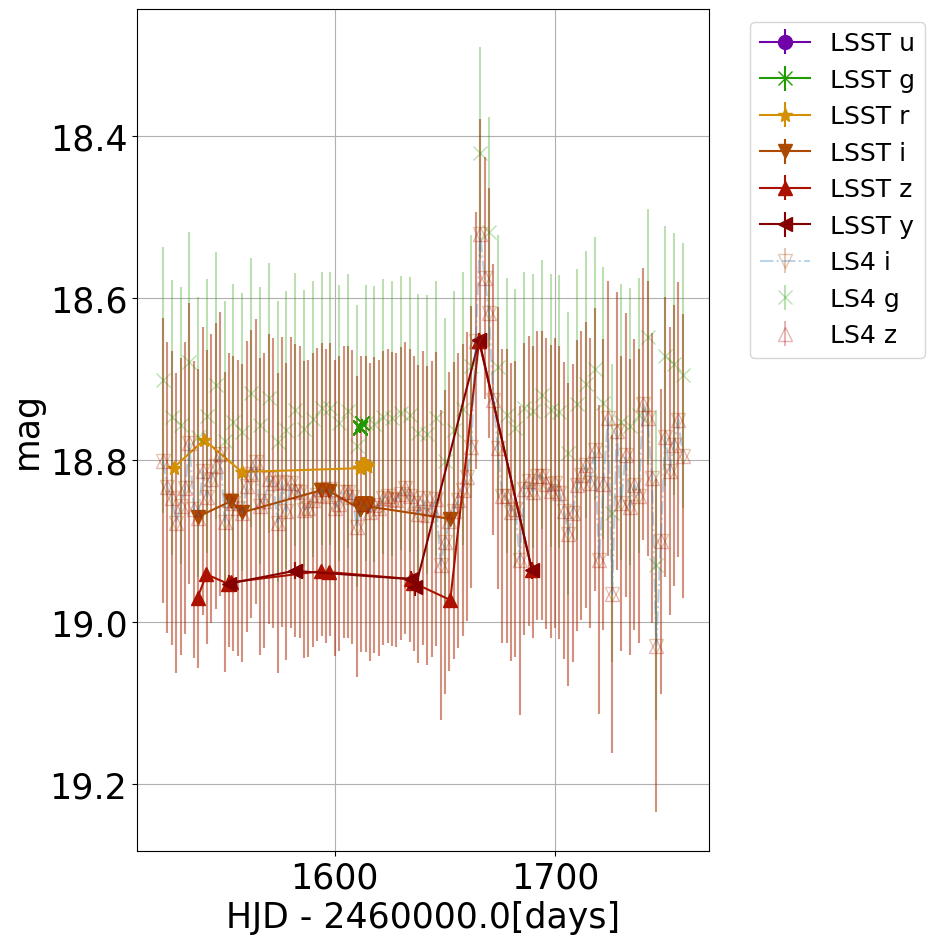

In [26]:
fig = plt.figure(1, (10, 10))
dt = 2460000.0 

plot_colors = {'u': '#6F02A8', 'g': '#209b01', 'r': '#d58f04', 'i': '#AC4B00', 'z':'#ac1000', 'y': '#850101'}
plot_symbols = {'u': 'o', 'g': 'x', 'r': '*', 'i': 'v', 'z': '^', 'y': '<', 'LS4_g': 'x', 'LS4_i': 'v', 'LS4_z': '^'}

# Plot simulated LSST lightcurves over the original dataset
for f, lc in sim_lcs.items():
    plt.errorbar(
        lc['HJD']-dt, lc['mag'], yerr=lc['mag_error'], 
        marker=plot_symbols[f], markerfacecolor=plot_colors[f], markeredgecolor=plot_colors[f], markersize=10, alpha=1.0,
        linestyle='-', ecolor=plot_colors[f], color=plot_colors[f], label='LSST '+f)

    #if f == 'i':
     #   orig_lc = lightcurves[f]
      #  plt.plot(orig_lc['HJD']-dt, orig_lc['mag']+mag_offset, marker='x', linestyle=' ', color=plot_colors[f], alpha=0.1)
       # plt.plot(orig_lc['HJD']-dt, interp_lc[f](orig_lc['HJD'])+mag_offset, marker='.', color=plot_colors[f], alpha=0.1, linestyle='-')

# Plot simulated LS4 lightcurves
use_ls4 = True 
if use_ls4:
    plt.errorbar(
            ls4_idata[:,0]-dt, ls4_idata[:,1], yerr=ls4_idata[:,2], 
            marker=plot_symbols['LS4_i'], markerfacecolor='none', markeredgecolor=plot_colors['i'], markersize=10,
            linestyle='-.', ecolor=plot_colors['i'], alpha=0.3, label='LS4 i')
    plt.errorbar(
            ls4_gdata[:,0]-dt, ls4_gdata[:,1], yerr=ls4_gdata[:,2], 
            marker=plot_symbols['LS4_g'], markerfacecolor='none', markeredgecolor=plot_colors['g'], markersize=10,
            linestyle=' ', ecolor=plot_colors['g'], alpha=0.3, label='LS4 g')
    plt.errorbar(
            ls4_idata[:,0]-dt, ls4_idata[:,1], yerr=ls4_idata[:,2], 
            marker=plot_symbols['LS4_z'], markerfacecolor='none', markeredgecolor=plot_colors['z'], markersize=10,
            linestyle=' ', ecolor=plot_colors['z'], alpha=0.3, label='LS4 z')

plt.rcParams.update({'font.size': 25})
plt.xlabel('HJD - ' + str(dt) + '[days]')
plt.ylabel('mag')
plt.gca().invert_yaxis()
plt.legend(bbox_to_anchor=(1.05, 1.0), fontsize=18)
plt.grid()

[xmin, xmax, ymin, ymax] = plt.axis() 

plt.fill_between([xmin,xmax], [ymin], y2=[23.5], color='grey', alpha=0.1)
plt.fill_between([xmin,xmax], [16.0], y2=[ymax], color='grey', alpha=0.1)
plt.axis([xmin, xmax, ymin, ymax])

#plt.show()
plt.tight_layout()
plt.savefig('/Users/rstreet/cassiopeia/GrantProposals/2025/NSF_AAG/LSSTMicrolensing/figures/lsst_v5_sim_dwarf_nova.png')